# Entrenamiento YOLO en GITHUB CON JUPYTER


Este notebook entrena un modelo YOLOv8 usando Ultralytics. Esta pensado para cumplir con la actividad: entrenamiento, pruebas y evidencias con bounding boxes.

Antes de ejecutar, sube este proyecto a Google Drive o a GitHub y coloca tu dataset en formato YOLO.

In [1]:
import shutil
from pathlib import Path

pred_origen = Path("runs/detect/evidencias/predicciones")
train_origen = Path("runs/detect/runs/detect/train")

pred_destino = Path("evidencias/predicciones")
metricas_destino = Path("evidencias/metricas")

pred_destino.mkdir(parents=True, exist_ok=True)
metricas_destino.mkdir(parents=True, exist_ok=True)

for img in list(pred_origen.glob("*.jpg")) + list(pred_origen.glob("*.png")):
    shutil.copy2(img, pred_destino / img.name)

for nombre in [
    "results.png",
    "results.csv",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "labels.jpg",
    "val_batch0_pred.jpg",
    "val_batch1_pred.jpg",
    "val_batch2_pred.jpg",
]:
    archivo = train_origen / nombre
    if archivo.exists():
        shutil.copy2(archivo, metricas_destino / nombre)

print("Listo")

Listo


## 2. Instalar dependencias

In [2]:
!pip install ultralytics opencv-python PyYAML tqdm


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python3 -m pip install --upgrade pip


## 3. DATASET




In [3]:
import os
from pathlib import Path

PROJECT_DIR = Path.cwd()
DATA_YAML = PROJECT_DIR / "data.yaml"

print("Carpeta actual:", PROJECT_DIR)
print("Existe data.yaml:", DATA_YAML.exists())
print(os.listdir(PROJECT_DIR))

Carpeta actual: /workspaces/PROYECTO-VISION-3ER-PARCIAL
Existe data.yaml: True
['data.yaml', 'yolov8n.pt', '.gitignore', 'requirements.txt', 'README.md', 'colab_entrenamiento_yolo.ipynb', 'evidencias', 'datasets', 'runs', 'src', '.git']


## 4. Definir rutas



In [4]:
from pathlib import Path
import os

PROJECT_DIR = Path.cwd()
DATA_YAML = PROJECT_DIR / "data.yaml"

print("PROJECT_DIR:", PROJECT_DIR)
print("DATA_YAML existe:", DATA_YAML.exists())
print(os.listdir(PROJECT_DIR))

PROJECT_DIR: /workspaces/PROYECTO-VISION-3ER-PARCIAL
DATA_YAML existe: True
['data.yaml', 'yolov8n.pt', '.gitignore', 'requirements.txt', 'README.md', 'colab_entrenamiento_yolo.ipynb', 'evidencias', 'datasets', 'runs', 'src', '.git']


## 5. Revisar `data.yaml`

El archivo debe apuntar a tu dataset. Ejemplo:

```yaml
path: datasets/mi_dataset
train: images/train
val: images/val
names:
  0: objeto
```

Si tu dataset esta en otra carpeta de Drive, usa una ruta absoluta en `path`.

In [5]:
!cat data.yaml

# Dataset para detectar perros y gatos.
# La ruta debe apuntar a la carpeta que contiene images/ y labels/.
path: datasets/mi_dataset
train: images/train
val: images/val

names:
  0: perro
  1: gato


## 6. Validar estructura del dataset

In [6]:
!python src/validate_dataset.py --dataset datasets/mi_dataset


Split: train
Imagenes encontradas: 522
Etiquetas encontradas: 522
Todas las imagenes tienen etiqueta correspondiente.

Split: val
Imagenes encontradas: 82
Etiquetas encontradas: 82
Todas las imagenes tienen etiqueta correspondiente.

Dataset listo para entrenamiento.


## 7. Entrenar YOLOv8

`yolov8n.pt` es ligero y recomendado para clase porque entrena rapido. Puedes cambiarlo por `yolov8s.pt` si quieres mejor precision y tienes mas tiempo de GPU.

In [7]:
!sudo apt-get update
!sudo apt-get install -y libgl1

Hit:1 https://packages.microsoft.com/repos/microsoft-ubuntu-noble-prod noble InRelease
Hit:2 http://security.ubuntu.com/ubuntu noble-security InRelease
Hit:3 http://archive.ubuntu.com/ubuntu noble InRelease
Hit:4 http://archive.ubuntu.com/ubuntu noble-updates InRelease
Hit:5 http://archive.ubuntu.com/ubuntu noble-backports InRelease
Reading package lists... Done
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
libgl1 is already the newest version (1.7.0-1build1).
0 upgraded, 0 newly installed, 0 to remove and 108 not upgraded.


In [9]:
!python src/train.py --data data.yaml --model yolov8n.pt --epochs 1 --imgsz 320 --batch 4

New https://pypi.org/project/ultralytics/8.4.72 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.161 🚀 Python-3.12.1 torch-2.12.1+cu130 CPU (AMD EPYC 9V74 80-Core Processor)
engine/trainer: agnostic_nms=False, amp=True, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=1, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=False, name=train5, nbs=64, nms=False, opset=None, optimize=False, optimizer

## 8. Revisar metricas del entrenamiento

Ultralytics guarda graficas como `results.png`, matriz de confusion y ejemplos de prediccion en `runs/detect/train/`.

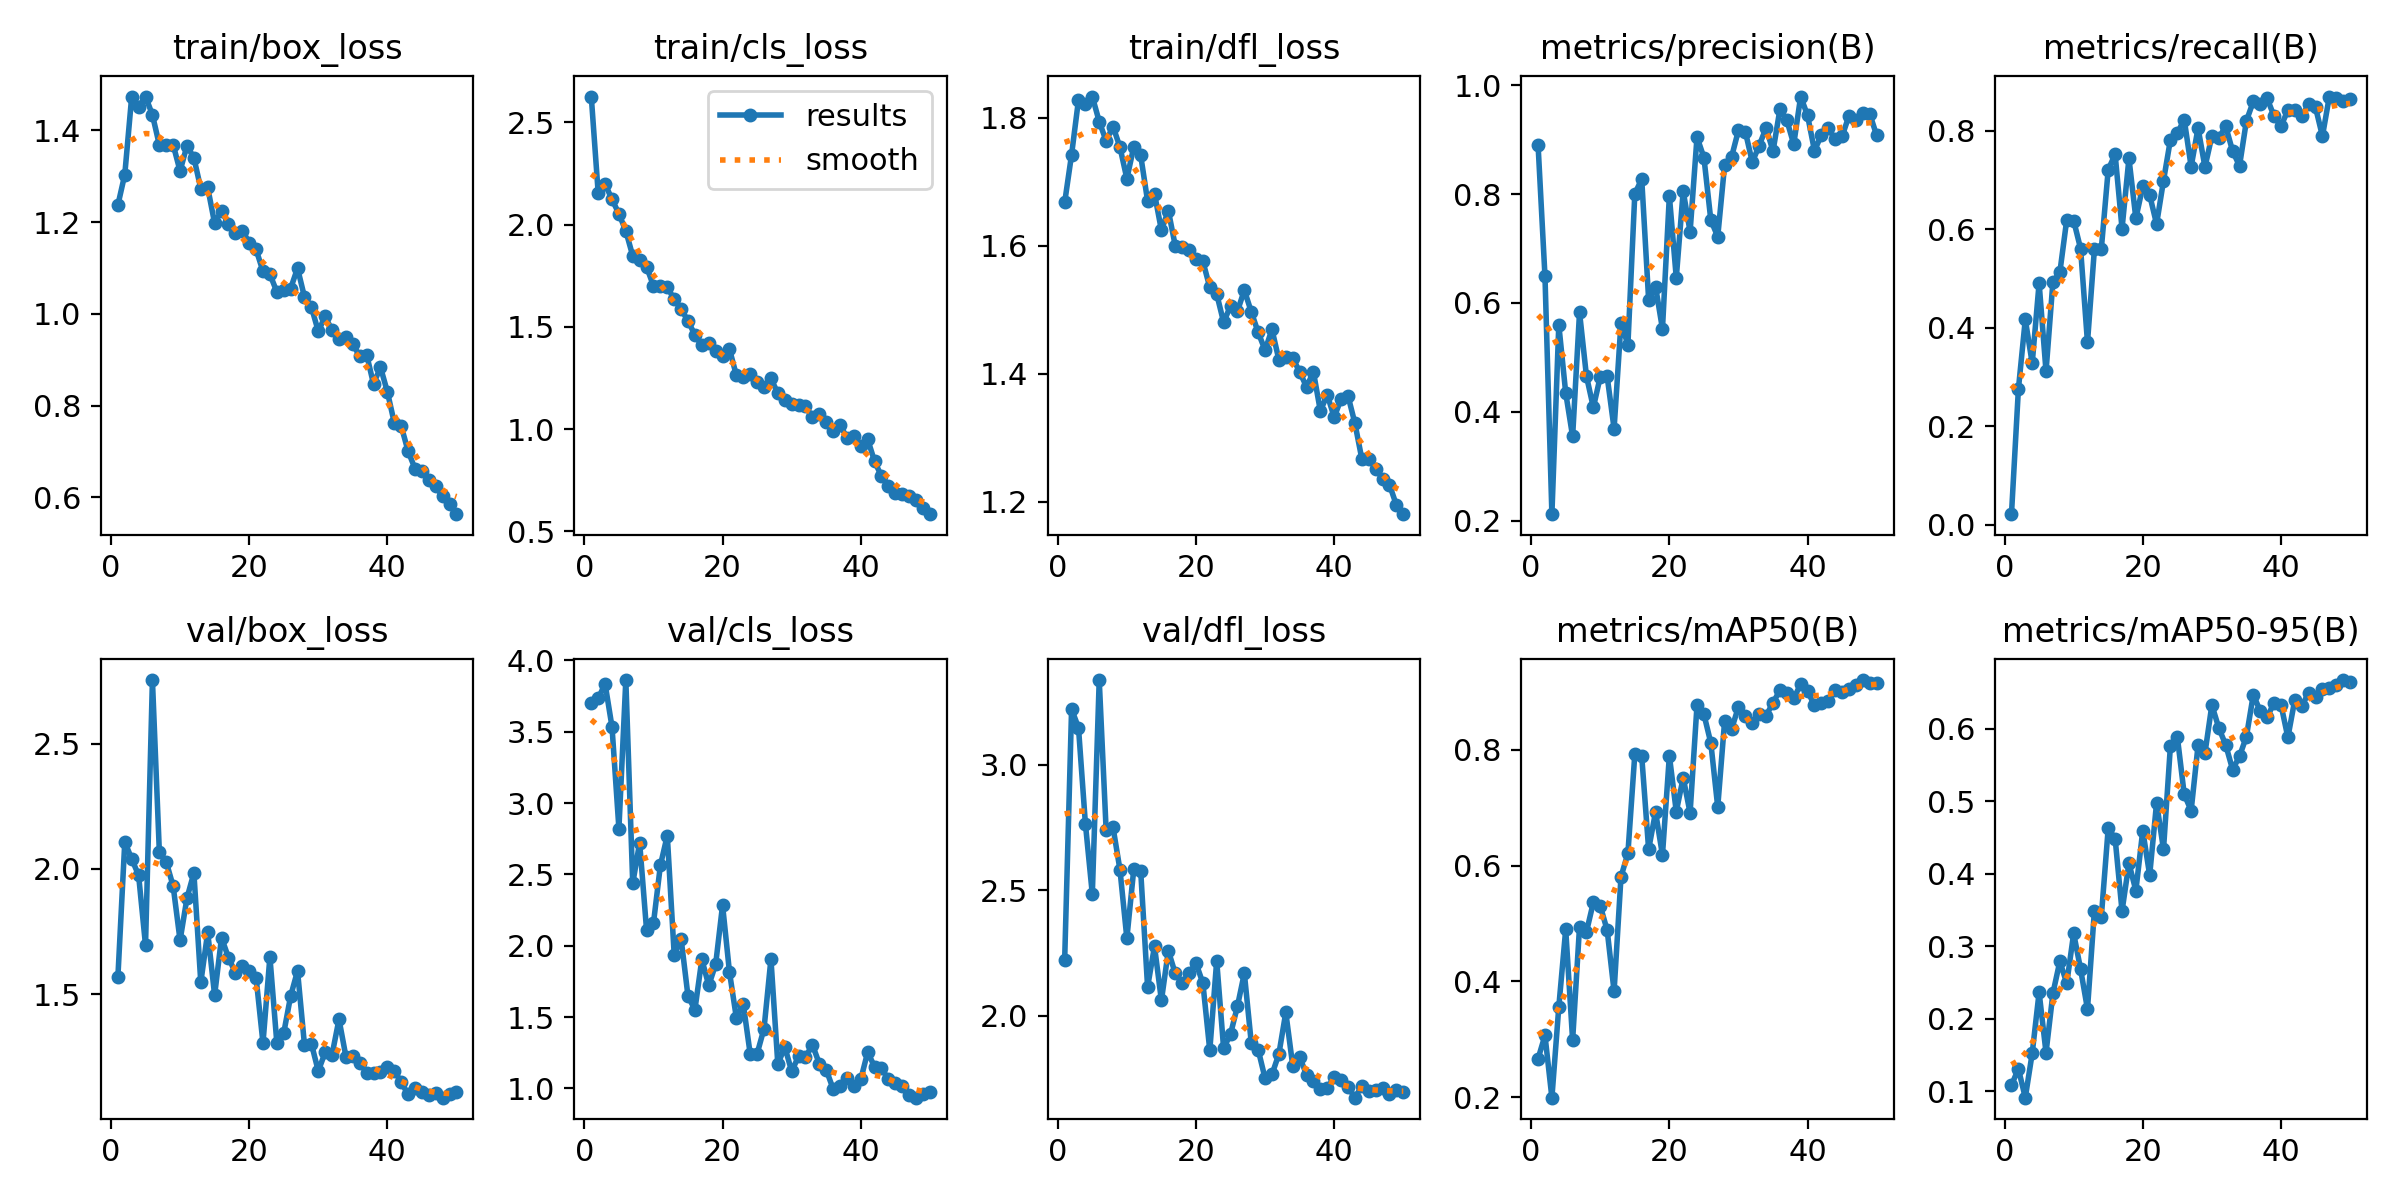

In [10]:
from pathlib import Path
from IPython.display import Image, display

metricas_dir = Path("evidencias/metricas")
results_img = metricas_dir / "results.png"

if results_img.exists():
    display(Image(filename=str(results_img)))
else:
    print("No esta results.png en evidencias/metricas.")
    print("Primero copia las metricas desde runs o termina el entrenamiento.")

## 9. Generar evidencias con bounding boxes

In [12]:
!python src/predict.py --weights "runs/detect/train5/weights/best.pt" --source datasets/mi_dataset/images/val --conf 0.25 --output evidencias/predicciones


image 1/82 /workspaces/PROYECTO-VISION-3ER-PARCIAL/datasets/mi_dataset/images/val/cat_val_00001.jpg: 320x320 2 gatos, 59.4ms
image 2/82 /workspaces/PROYECTO-VISION-3ER-PARCIAL/datasets/mi_dataset/images/val/cat_val_00002.jpg: 320x320 (no detections), 42.6ms
image 3/82 /workspaces/PROYECTO-VISION-3ER-PARCIAL/datasets/mi_dataset/images/val/cat_val_00003.jpg: 320x320 (no detections), 45.1ms
image 4/82 /workspaces/PROYECTO-VISION-3ER-PARCIAL/datasets/mi_dataset/images/val/cat_val_00004.jpg: 320x320 (no detections), 44.5ms
image 5/82 /workspaces/PROYECTO-VISION-3ER-PARCIAL/datasets/mi_dataset/images/val/cat_val_00005.jpg: 320x320 1 gato, 62.0ms
image 6/82 /workspaces/PROYECTO-VISION-3ER-PARCIAL/datasets/mi_dataset/images/val/cat_val_00006.jpg: 320x320 1 gato, 41.2ms
image 7/82 /workspaces/PROYECTO-VISION-3ER-PARCIAL/datasets/mi_dataset/images/val/cat_val_00007.jpg: 320x320 (no detections), 41.2ms
image 8/82 /workspaces/PROYECTO-VISION-3ER-PARCIAL/datasets/mi_dataset/images/val/cat_val_0000

## 10. Mostrar algunas evidencias

Imagenes encontradas: 89
evidencias/predicciones/dog_val_00039.jpg


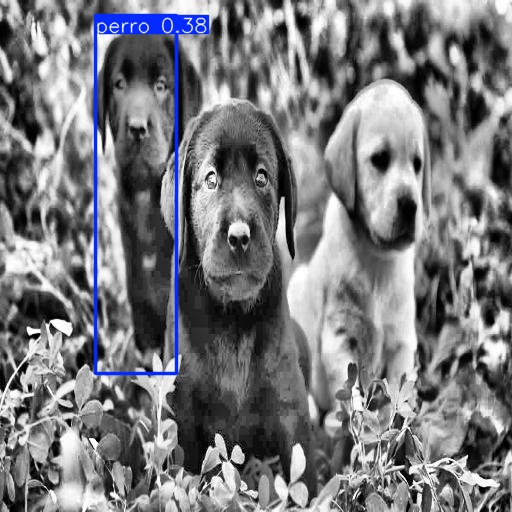

evidencias/predicciones/dogtest_val_00014.jpg


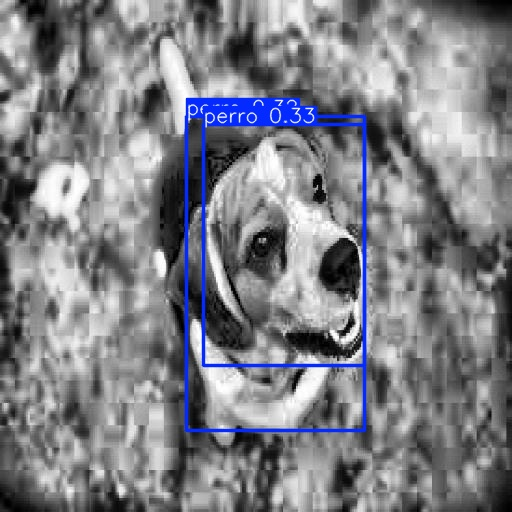

evidencias/predicciones/dog_val_00034.jpg


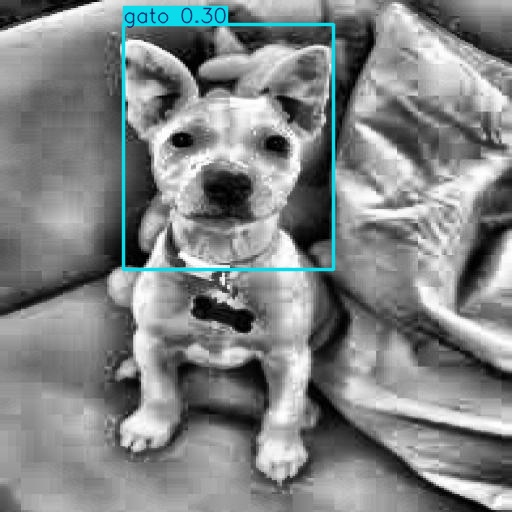

evidencias/predicciones/dog_val_00040.jpg


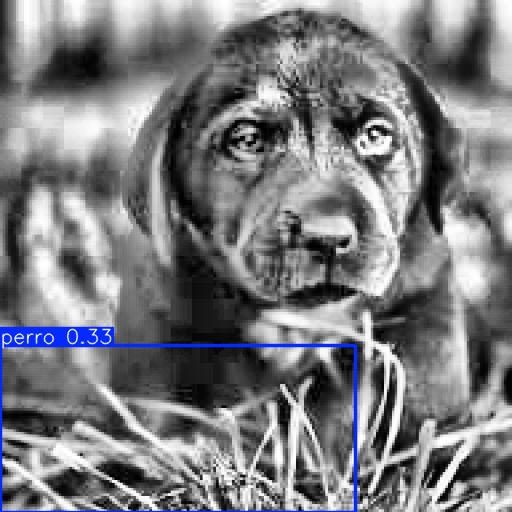

evidencias/predicciones/cat_val_00004.jpg


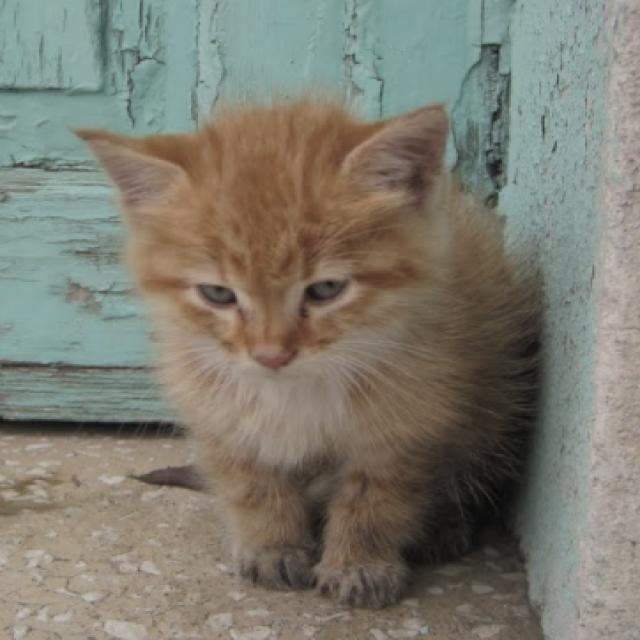

evidencias/predicciones/cat_val_00014.jpg


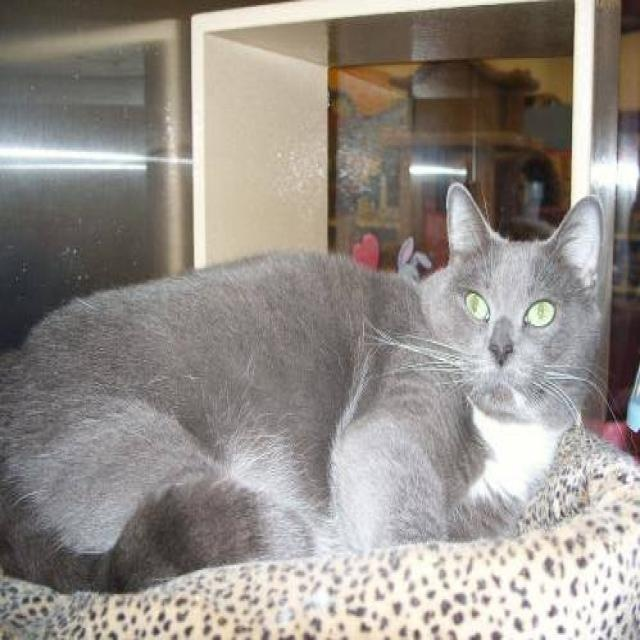

evidencias/predicciones/dog_val_00004.jpg


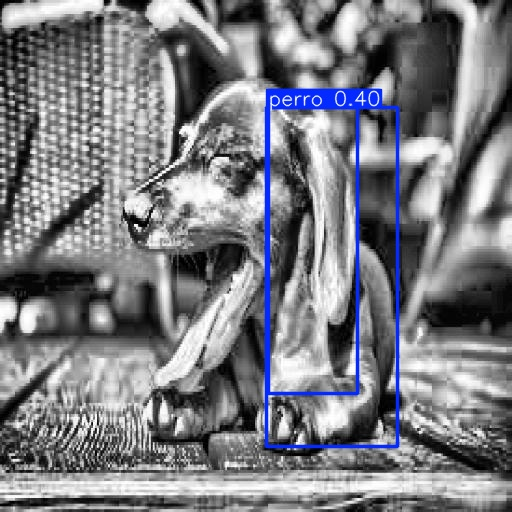

evidencias/predicciones/cat_val_00008.jpg


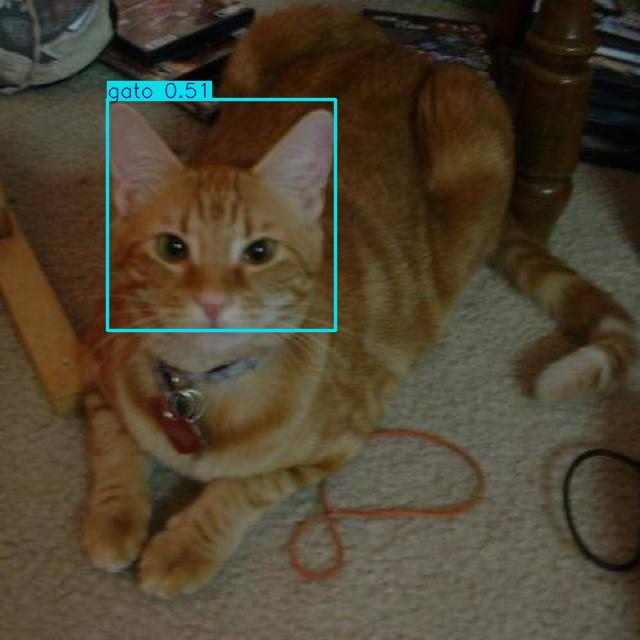

evidencias/predicciones/dogtest_val_00001.jpg


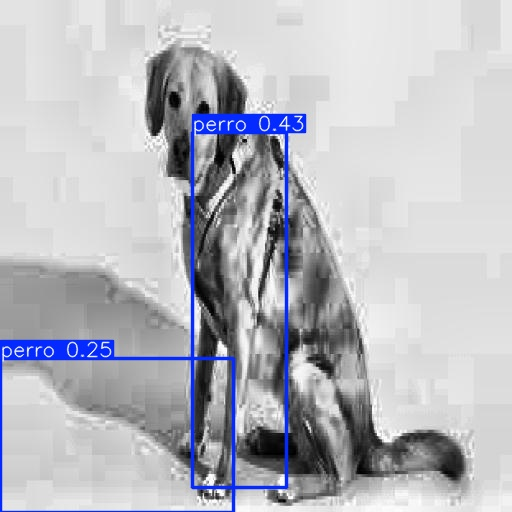

evidencias/predicciones/dog_val_00027.jpg


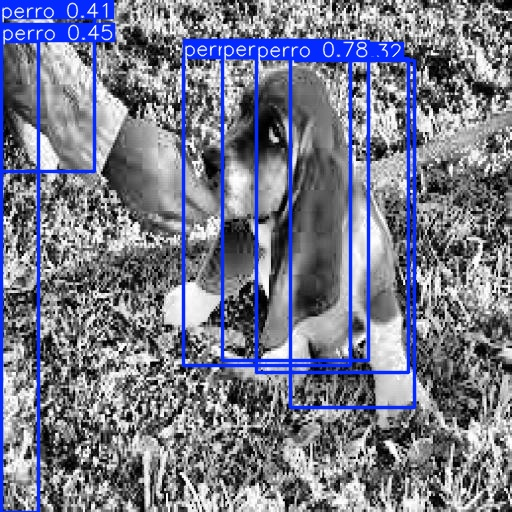

In [13]:
from pathlib import Path
from IPython.display import Image, display

imagenes = list(Path("evidencias").rglob("*.jpg")) + list(Path("evidencias").rglob("*.png"))

print("Imagenes encontradas:", len(imagenes))

for img in imagenes[:10]:
    print(img)
    display(Image(filename=str(img), width=500))

## 11. Descargar evidencias


In [ ]:
import shutil
from pathlib import Path

origen = Path("runs/detect/evidencias/predicciones")
destino = Path("evidencias/predicciones")

destino.mkdir(parents=True, exist_ok=True)

for img in list(origen.glob("*.jpg")) + list(origen.glob("*.png")):
    shutil.copy2(img, destino / img.name)

print("Imagenes copiadas a:", destino)
print("Total:", len(list(destino.glob("*"))))

Imagenes copiadas a: evidencias/predicciones
Total: 82
